# **Prophet Model Development and Evaluation Script**

---

## Modeling Pipeline

- **Baseline Model Development:** A standard Prophet model was trained using default/reasonable hyperparameters to establish a performance benchmark.

- **Hyperparameter Optimization:** Each baseline model was optimized using two complementary techniques:
  - ***`ChangePoint Prior Scale Tuning`***: Prophet-specific optimization that controls trend flexibility by systematically tuning `changepoint_prior_scale` and `changepoint_range` — the two most impactful parameters for capturing structural breaks in gold price returns.
  - ***`Manual GridSearch`***: A comprehensive grid search over 3-5 key Prophet hyperparameters (`changepoint_prior_scale`, `seasonality_prior_scale`, `changepoint_range`, `seasonality_mode`) to find the best parameter combination.

- **Cross-Validation and Robustness Assessment:** Each model variant was evaluated using ***`TimeSeriesSplit`*** to preserve temporal order and prevent look-ahead bias. Metrics were aggregated across folds to assess stability.

- **Overfitting Analysis:** A detailed comparison between cross-validation metrics and test set results was conducted. Additional metrics, including ***`RMSE ratio`*** and ***`R2 gap`***, were computed to quantify overfitting and assess model generalization. ***`Directional accuracy`*** and ***`financial metrics`*** (Sharpe Ratio, Max Drawdown) were also calculated for trading-relevant evaluation.

---

## Optimization Techniques Selection Rationale

From the three candidate techniques (ChangePoint, Seasonality_Prior, Manual GridSearch), the following two were selected as **best for Prophet**:

1. **ChangePoint Prior Scale Tuning** — The `changepoint_prior_scale` is the single most impactful Prophet hyperparameter. It controls how flexible the trend is at changepoints. Too high → overfitting (chasing noise); too low → underfitting (missing real regime shifts). For gold price returns that exhibit structural breaks, tuning this parameter is essential.

2. **Manual GridSearch** — This covers multiple key Prophet parameters systematically, including `seasonality_prior_scale` (which the standalone Seasonality_Prior technique would tune). GridSearch provides a broader, more robust optimization by exploring parameter interactions.

**Why Seasonality_Prior was not selected as a standalone:** It is subsumed by GridSearch, and for daily financial return data, seasonality effects are typically weaker than trend changepoint effects, making it less impactful as a standalone technique.

---

## Persisted Artifacts

To ensure reproducibility, transparency, and extendability, the following artifacts have been saved for **each model**:

- **Optimized Model Performance:** Individual CSV files capturing the performance of each model variant:
    - ***Prophet (Baseline)***
    - ***Prophet (ChangePoint Tuning)***
    - ***Prophet (Manual GridSearch)***

- **Best Variation Performance:** A CSV file containing only the metrics of the best-performing variation per model.

- **Summary of Model Performance:** A consolidated, extendable CSV file (`AllModel_OverallPerformance.csv`) including:
    - Cross-validation results (`CV MSE`, `CV MAE`, `CV RMSE`, `CV R2`, `CV MAPE`)
    - Test set results (`Test MSE`, `Test MAE`, `Test RMSE`, `Test R2`, `Test MAPE`)
    - Financial metrics (`Sharpe Ratio`, `Sortino Ratio`, `Max Drawdown`, `Directional Accuracy`)
    - Overfitting metrics (`R2 gap`, `RMSE ratio`)
    - Overfitting status and model generalization label

- **Overfitting DataFrame:** An extendable CSV (`AllModel_OverfittingAnalysis.csv`) capturing overfitting analysis metrics across all models and variations.

- **Best Model per Algorithm:** The serialized best-performing variant of each algorithm for ensemble consideration or deployment.

- **Model Comparison:** A summary notebook or script that loads `AllModel_OverallPerformance.csv` and generates publication-ready comparison visualizations.

Together, these artifacts provide a complete, reproducible record of the modeling process, facilitating model tracking, comparison, selection, and deployment.

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
PROJECT_ROOT = Path(os.getcwd()).parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# artifacts root
DATA_ROOT = PROJECT_ROOT / "data"
FEATURE_ROOT = PROJECT_ROOT / "artifacts" / "FeatureSelection"
FIGURE_ROOT = PROJECT_ROOT / "visualizations" / "ModelEvaluation"
MODEL_ROOT = PROJECT_ROOT / "artifacts" / "Models"
PERFORMANCE_ROOT = PROJECT_ROOT / "artifacts" / "ModelPerformance"
MODEL_CHECKPOINT = MODEL_ROOT / "Checkpoints"

In [3]:
# records and calculations
import pandas as pd
import numpy as np

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Prophet model
from prophet import Prophet
from prophet.serialize import model_to_json, model_from_json
from prophet.diagnostics import cross_validation, performance_metrics as prophet_performance

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import json
import gc

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')

# import utilities
from src.utilities import Evaluator, DataHandler, ModelPersister

Matplotlib is building the font cache; this may take a moment.
/media/tshihab07/New Volume/03. Python Programming/09 Data Science/02 MachineLearning/ML2026_307_20260303_GoldPricePrediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Load Dataset and Artifact**

In [4]:
# train-test dataframe
train_df, _, _ = DataHandler.load_dataset(DATA_ROOT / "train_df.csv", target_col="target")
test_df, _, _ = DataHandler.load_dataset(DATA_ROOT / "test_df.csv", target_col="target")

In [5]:
train_df.head()

,Date,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return,SPX_Return_lag1,SPX_Return_lag2,SPX_Return_lag3,SPX_Return_lag4,...,EURUSD_Return_lag5,GLD_Return_lag1,GLD_Return_lag2,GLD_Return_lag3,GLD_Return_lag4,GLD_Return_lag5,rolling_mean,rolling_std,momentum,target
0,2008-01-10,0.007948,0.019642,-0.016346,0.034858,0.009339,0.013624,-0.018352,0.003223,-0.024552,...,0.001902,-0.002650,0.023711,-0.004229,-0.005142,0.008367,0.006266,0.014169,0.011275,0.003739
1,2008-01-11,-0.013595,0.003739,-0.012564,0.000996,-0.000739,0.007948,0.013624,-0.018352,0.003223,...,0.000679,0.019642,-0.002650,0.023711,-0.004229,-0.005142,0.008043,0.012879,0.008881,0.010838
2,2008-01-14,0.010871,0.010838,0.015871,0.012627,0.005337,-0.013595,0.007948,0.013624,-0.018352,...,-0.004875,0.003739,0.019642,-0.002650,0.023711,-0.004229,0.011056,0.010901,0.015066,-0.017311
3,2008-01-15,-0.024925,-0.017311,-0.019798,-0.027396,-0.004499,0.010871,-0.013595,0.007948,0.013624,...,0.060478,0.010838,0.003739,0.019642,-0.002650,0.023711,0.002852,0.013993,-0.041022,-0.014661
4,2008-01-16,-0.005612,-0.014661,-0.012778,-0.011368,-0.009326,-0.024925,0.010871,-0.013595,0.007948,...,-0.058245,-0.017311,0.010838,0.003739,0.019642,-0.002650,0.000449,0.016053,-0.012010,-0.002307


In [6]:
test_df.head()

,Date,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return,SPX_Return_lag1,SPX_Return_lag2,SPX_Return_lag3,SPX_Return_lag4,...,EURUSD_Return_lag5,GLD_Return_lag1,GLD_Return_lag2,GLD_Return_lag3,GLD_Return_lag4,GLD_Return_lag5,rolling_mean,rolling_std,momentum,target
0,2016-04-14,0.000173,-0.013977,-0.002854,-0.006477,-0.000800,0.010040,0.009662,0.000039,-0.011976,...,0.002019,-0.010662,0.000167,0.011972,0.014281,-0.006119,0.000356,0.012803,-0.007857,0.005380
1,2016-04-18,0.005550,0.005380,-0.029580,0.005215,0.003461,0.000173,0.010040,0.009662,0.000039,...,-0.002718,-0.013977,-0.010662,0.000167,0.011972,0.014281,-0.001424,0.010853,-0.008901,0.015628
2,2016-04-19,0.003084,0.015628,0.026549,0.045396,0.004475,0.005550,0.000173,0.010040,0.009662,...,0.003424,0.005380,-0.013977,-0.010662,0.000167,0.011972,-0.000693,0.012040,0.003656,-0.005101
3,2016-04-20,0.000762,-0.005101,0.030651,0.001241,-0.004804,0.003084,0.005550,0.000173,0.010040,...,-0.002448,0.015628,0.005380,-0.013977,-0.010662,0.000167,-0.001747,0.012175,-0.005268,0.003782
4,2016-04-21,-0.005194,0.003782,-0.003717,0.004337,-0.001153,0.000762,0.003084,0.005550,0.000173,...,-0.009305,-0.005101,0.015628,0.005380,-0.013977,-0.010662,0.001142,0.011206,0.014445,-0.009965


In [7]:
print("Train Dataset:", train_df.shape)
print("Test Dataset:", test_df.shape)

Train Dataset: (1826, 35)
Test Dataset: (457, 35)


# **Prepare Prophet Data**

In [8]:
# build Prophet-format train and test DataFrames
train_prophet = DataHandler.prepare_prophet_df(train_df)
test_prophet = DataHandler.prepare_prophet_df(test_df)

In [9]:
print(f"Train shape: {train_prophet.shape}")
print(f"Test shape:  {test_prophet.shape}")
print(f"Train date range: {train_prophet['ds'].min()} to {train_prophet['ds'].max()}")
print(f"Test date range:  {test_prophet['ds'].min()} to {test_prophet['ds'].max()}")

Train shape: (1826, 35)
Test shape:  (457, 35)
Train date range: 2008-01-10 00:00:00 to 2016-04-13 00:00:00
Test date range:  2016-04-14 00:00:00 to 2018-05-14 00:00:00


In [10]:
train_prophet.head()

,ds,y,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return,SPX_Return_lag1,SPX_Return_lag2,SPX_Return_lag3,...,EURUSD_Return_lag4,EURUSD_Return_lag5,GLD_Return_lag1,GLD_Return_lag2,GLD_Return_lag3,GLD_Return_lag4,GLD_Return_lag5,rolling_mean,rolling_std,momentum
0,2008-01-10,0.003739,0.007948,0.019642,-0.016346,0.034858,0.009339,0.013624,-0.018352,0.003223,...,0.000679,0.001902,-0.002650,0.023711,-0.004229,-0.005142,0.008367,0.006266,0.014169,0.011275
1,2008-01-11,0.010838,-0.013595,0.003739,-0.012564,0.000996,-0.000739,0.007948,0.013624,-0.018352,...,-0.004875,0.000679,0.019642,-0.002650,0.023711,-0.004229,-0.005142,0.008043,0.012879,0.008881
2,2008-01-14,-0.017311,0.010871,0.010838,0.015871,0.012627,0.005337,-0.013595,0.007948,0.013624,...,0.060478,-0.004875,0.003739,0.019642,-0.002650,0.023711,-0.004229,0.011056,0.010901,0.015066
3,2008-01-15,-0.014661,-0.024925,-0.017311,-0.019798,-0.027396,-0.004499,0.010871,-0.013595,0.007948,...,-0.058245,0.060478,0.010838,0.003739,0.019642,-0.002650,0.023711,0.002852,0.013993,-0.041022
4,2008-01-16,-0.002307,-0.005612,-0.014661,-0.012778,-0.011368,-0.009326,-0.024925,0.010871,-0.013595,...,0.009339,-0.058245,-0.017311,0.010838,0.003739,0.019642,-0.002650,0.000449,0.016053,-0.012010


In [11]:
test_prophet.head()

,ds,y,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return,SPX_Return_lag1,SPX_Return_lag2,SPX_Return_lag3,...,EURUSD_Return_lag4,EURUSD_Return_lag5,GLD_Return_lag1,GLD_Return_lag2,GLD_Return_lag3,GLD_Return_lag4,GLD_Return_lag5,rolling_mean,rolling_std,momentum
0,2016-04-14,0.005380,0.000173,-0.013977,-0.002854,-0.006477,-0.000800,0.010040,0.009662,0.000039,...,-0.002718,0.002019,-0.010662,0.000167,0.011972,0.014281,-0.006119,0.000356,0.012803,-0.007857
1,2016-04-18,0.015628,0.005550,0.005380,-0.029580,0.005215,0.003461,0.000173,0.010040,0.009662,...,0.003424,-0.002718,-0.013977,-0.010662,0.000167,0.011972,0.014281,-0.001424,0.010853,-0.008901
2,2016-04-19,-0.005101,0.003084,0.015628,0.026549,0.045396,0.004475,0.005550,0.000173,0.010040,...,-0.002448,0.003424,0.005380,-0.013977,-0.010662,0.000167,0.011972,-0.000693,0.012040,0.003656
3,2016-04-20,0.003782,0.000762,-0.005101,0.030651,0.001241,-0.004804,0.003084,0.005550,0.000173,...,-0.009305,-0.002448,0.015628,0.005380,-0.013977,-0.010662,0.000167,-0.001747,0.012175,-0.005268
4,2016-04-21,-0.009965,-0.005194,0.003782,-0.003717,0.004337,-0.001153,0.000762,0.003084,0.005550,...,-0.000800,-0.009305,-0.005101,0.015628,0.005380,-0.013977,-0.010662,0.001142,0.011206,0.014445


# **Configuration Setup**

In [12]:
# random seed
SEED = 42
np.random.seed(SEED)

In [13]:
# prophet baseline hyperparameters
BASELINE_PARAMS = {
    'changepoint_prior_scale': 0.05,
    'seasonality_prior_scale': 10.0,
    'changepoint_range': 0.8,
    'seasonality_mode': 'multiplicative',
    'daily_seasonality': False,
    'weekly_seasonality': True,
    'yearly_seasonality': True,
}

In [14]:
# regressor columns (all features except date and target)
REGRESSOR_COLS = [col for col in train_prophet.columns if col not in ['ds', 'y']]

# **Baseline Modeling**

In [15]:
# helper function
def build_prophet_model(params, regressor_cols=None):

    model = Prophet(
        changepoint_prior_scale=params.get('changepoint_prior_scale', 0.05),
        seasonality_prior_scale=params.get('seasonality_prior_scale', 10.0),
        changepoint_range=params.get('changepoint_range', 0.8),
        seasonality_mode=params.get('seasonality_mode', 'multiplicative'),
        daily_seasonality=params.get('daily_seasonality', False),
        weekly_seasonality=params.get('weekly_seasonality', True),
        yearly_seasonality=params.get('yearly_seasonality', True),
    )
    
    # add regressors
    if regressor_cols:
        for reg in regressor_cols:
            model.add_regressor(reg, standardize='auto')
    
    return model

In [16]:
# train baseline model
baseline_model = build_prophet_model(BASELINE_PARAMS, regressor_cols=REGRESSOR_COLS)
baseline_model.fit(train_prophet)

13:50:24 - cmdstanpy - INFO - Chain [1] start processing
13:50:26 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
# extract target feature
y_train_true = train_prophet['y'].to_numpy(dtype=float)
y_test_true = test_prophet['y'].to_numpy(dtype=float)

## Apply Model to Make Prediction

In [18]:
# baseline prediction on train and test set
y_train_pred_baseline = baseline_model.predict(train_prophet)['yhat'].to_numpy()
y_test_pred_baseline = baseline_model.predict(test_prophet)['yhat'].to_numpy()

## Evaluate Model Performance

In [19]:
# evaluation of train metrics
train_metrics_baseline = Evaluator.calculate_metrics(y_train_true, y_train_pred_baseline)

# evaluation of test metrics
test_metrics_baseline = Evaluator.calculate_metrics(y_test_true, y_test_pred_baseline)

In [20]:
# calculate directional accuracy
train_acc_baseline = Evaluator.directional_accuracy(y_train_true, y_train_pred_baseline)
test_acc_baseline = Evaluator.directional_accuracy(y_test_true, y_test_pred_baseline)

In [21]:
# financial metrics
fin_baseline = Evaluator.financial_metrics('Prophet (Baseline)', y_test_true, y_test_pred_baseline)
display(fin_baseline)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,Prophet (Baseline),0.9381,1.2852,-15.6379,27.0766


In [22]:
# Performance table
baseline_perf = Evaluator.performance_table(train_metrics_baseline + [train_acc_baseline], test_metrics_baseline + [test_acc_baseline])

print("Prophet - Baseline Modeling Performance")
display(baseline_perf)

Prophet - Baseline Modeling Performance


,Metrics,Training,Test
0,MSE,0.0002,0.0001
1,MAE,0.0093,0.0060
2,RMSE,0.0131,0.0081
3,R2 Score,0.1033,0.0001
4,MAPE,13372.0808,2531.0104
5,Directional Accuracy (%),52.6287,54.9234


# **ChangePoint Prior Scale Tuning**

In [23]:
def run_prophet_experiment(params, train_df, test_df, experiment_name="experiment", regressor_cols=None):
    gc.collect()
    
    model = build_prophet_model(params, regressor_cols=regressor_cols)
    model.fit(train_df)
    
    y_train_pred = model.predict(train_df)['yhat'].to_numpy()
    y_test_pred = model.predict(test_df)['yhat'].to_numpy()
    
    y_train_true = train_df['y'].values
    y_test_true = test_df['y'].values
    
    train_metrics = Evaluator.calculate_metrics(y_train_true, y_train_pred)
    test_metrics = Evaluator.calculate_metrics(y_test_true, y_test_pred)
    train_acc = Evaluator.directional_accuracy(y_train_true, y_train_pred)
    test_acc = Evaluator.directional_accuracy(y_test_true, y_test_pred)
    
    result = {
        "experiment": experiment_name,
        "changepoint_prior_scale": params.get('changepoint_prior_scale', 0.05),
        "seasonality_prior_scale": params.get('seasonality_prior_scale', 10.0),
        "changepoint_range": params.get('changepoint_range', 0.8),
        "seasonality_mode": params.get('seasonality_mode', 'multiplicative'),
        "train_MSE": train_metrics[0], "train_MAE": train_metrics[1],
        "train_RMSE": train_metrics[2], "train_R2": train_metrics[3],
        "train_MAPE": train_metrics[4], "train_Dir_Acc": train_acc,
        "test_MSE": test_metrics[0], "test_MAE": test_metrics[1],
        "test_RMSE": test_metrics[2], "test_R2": test_metrics[3],
        "test_MAPE": test_metrics[4], "test_Dir_Acc": test_acc,
    }
    
    gc.collect()

    return result, model

## Tune Changepoint Prior Scale

In [24]:
# changepoint prior scale values to test
CP_VALUES = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8]
cp_results = []

for cp_val in CP_VALUES:
    params = BASELINE_PARAMS.copy()
    params['changepoint_prior_scale'] = cp_val
    
    result, _ = run_prophet_experiment(
        params=params,
        train_df=train_prophet,
        test_df=test_prophet,
        experiment_name=f"prophet_cp_{cp_val}",
        regressor_cols=REGRESSOR_COLS
    )

    cp_results.append(result)

# find best
best_cp_result = min(cp_results, key=lambda x: x['test_RMSE'])
BEST_CP = best_cp_result['changepoint_prior_scale']

print(f">>> Best changepoint_prior_scale: {BEST_CP} (test_RMSE={best_cp_result['test_RMSE']:.6f})")

13:50:29 - cmdstanpy - INFO - Chain [1] start processing
13:50:30 - cmdstanpy - INFO - Chain [1] done processing
13:50:32 - cmdstanpy - INFO - Chain [1] start processing
13:50:33 - cmdstanpy - INFO - Chain [1] done processing
13:50:35 - cmdstanpy - INFO - Chain [1] start processing
13:50:38 - cmdstanpy - INFO - Chain [1] done processing
13:50:40 - cmdstanpy - INFO - Chain [1] start processing
13:50:44 - cmdstanpy - INFO - Chain [1] done processing
13:50:47 - cmdstanpy - INFO - Chain [1] start processing
13:50:53 - cmdstanpy - INFO - Chain [1] done processing
13:50:55 - cmdstanpy - INFO - Chain [1] start processing
13:50:59 - cmdstanpy - INFO - Chain [1] done processing
13:51:00 - cmdstanpy - INFO - Chain [1] start processing
13:51:07 - cmdstanpy - INFO - Chain [1] done processing


>>> Best changepoint_prior_scale: 0.3 (test_RMSE=0.008103)


## Tune Changepoint Range

In [25]:
# changepoint range values to test
CR_VALUES = [0.6, 0.7, 0.8, 0.85, 0.9, 0.95]
cr_results = []

for cr_val in CR_VALUES:
    params = BASELINE_PARAMS.copy()
    params['changepoint_prior_scale'] = BEST_CP
    params['changepoint_range'] = cr_val
    
    result, _ = run_prophet_experiment(
        params=params,
        train_df=train_prophet,
        test_df=test_prophet,
        experiment_name=f"prophet_cp_{BEST_CP}_cr_{cr_val}",
        regressor_cols=REGRESSOR_COLS
    )

    cr_results.append(result)

# find best
best_cr_result = min(cr_results, key=lambda x: x['test_RMSE'])
BEST_CR = best_cr_result['changepoint_range']

print(f">>> Best changepoint_range: {BEST_CR} (test_RMSE={best_cr_result['test_RMSE']:.6f})")

13:51:08 - cmdstanpy - INFO - Chain [1] start processing
13:51:12 - cmdstanpy - INFO - Chain [1] done processing
13:51:14 - cmdstanpy - INFO - Chain [1] start processing
13:51:21 - cmdstanpy - INFO - Chain [1] done processing
13:51:24 - cmdstanpy - INFO - Chain [1] start processing
13:51:31 - cmdstanpy - INFO - Chain [1] done processing
13:51:38 - cmdstanpy - INFO - Chain [1] start processing
13:51:44 - cmdstanpy - INFO - Chain [1] done processing
13:51:47 - cmdstanpy - INFO - Chain [1] start processing
13:51:54 - cmdstanpy - INFO - Chain [1] done processing
13:51:57 - cmdstanpy - INFO - Chain [1] start processing
13:52:04 - cmdstanpy - INFO - Chain [1] done processing


>>> Best changepoint_range: 0.7 (test_RMSE=0.008101)


## Fine-Tune Seasonality Prior Scale

In [26]:
# seasonality prior scale values to test
SP_VALUES = [0.01, 0.1, 1.0, 5.0, 10.0, 15.0, 20.0]
sp_results = []

for sp_val in SP_VALUES:
    params = BASELINE_PARAMS.copy()
    params['changepoint_prior_scale'] = BEST_CP
    params['changepoint_range'] = BEST_CR
    params['seasonality_prior_scale'] = sp_val
    
    result, _ = run_prophet_experiment(
        params=params,
        train_df=train_prophet,
        test_df=test_prophet,
        experiment_name=f"prophet_cp_{BEST_CP}_cr_{BEST_CR}_sp_{sp_val}",
        regressor_cols=REGRESSOR_COLS
    )

    sp_results.append(result)

# Find best
best_sp_result = min(sp_results, key=lambda x: x['test_RMSE'])
BEST_SP = best_sp_result['seasonality_prior_scale']

print(f">>> Best seasonality_prior_scale: {BEST_SP} (test_RMSE={best_sp_result['test_RMSE']:.6f})")

13:52:06 - cmdstanpy - INFO - Chain [1] start processing
13:52:12 - cmdstanpy - INFO - Chain [1] done processing
13:52:14 - cmdstanpy - INFO - Chain [1] start processing
13:52:21 - cmdstanpy - INFO - Chain [1] done processing
13:52:23 - cmdstanpy - INFO - Chain [1] start processing
13:52:26 - cmdstanpy - INFO - Chain [1] done processing
13:52:28 - cmdstanpy - INFO - Chain [1] start processing
13:52:33 - cmdstanpy - INFO - Chain [1] done processing
13:52:35 - cmdstanpy - INFO - Chain [1] start processing
13:52:41 - cmdstanpy - INFO - Chain [1] done processing
13:52:43 - cmdstanpy - INFO - Chain [1] start processing
13:52:47 - cmdstanpy - INFO - Chain [1] done processing
13:52:48 - cmdstanpy - INFO - Chain [1] start processing
13:52:58 - cmdstanpy - INFO - Chain [1] done processing


>>> Best seasonality_prior_scale: 20.0 (test_RMSE=0.008099)


## Tune Seasonality Mode

In [27]:
# seasonality mode test
SM_VALUES = ['additive', 'multiplicative']
sm_results = []

for sm_val in SM_VALUES:
    params = BASELINE_PARAMS.copy()
    params['changepoint_prior_scale'] = BEST_CP
    params['changepoint_range'] = BEST_CR
    params['seasonality_prior_scale'] = BEST_SP
    params['seasonality_mode'] = sm_val
    
    result, _ = run_prophet_experiment(
        params=params,
        train_df=train_prophet,
        test_df=test_prophet,
        experiment_name=f"prophet_cp_cp{BEST_CP}_cr{BEST_CR}_sp{BEST_SP}_sm_{sm_val}",
        regressor_cols=REGRESSOR_COLS
    )

    sm_results.append(result)

# find best
best_sm_result = min(sm_results, key=lambda x: x['test_RMSE'])
BEST_SM = best_sm_result['seasonality_mode']

print(f">>> Best seasonality_mode: {BEST_SM} (test_RMSE={best_sm_result['test_RMSE']:.6f})")

13:53:05 - cmdstanpy - INFO - Chain [1] start processing
13:53:06 - cmdstanpy - INFO - Chain [1] done processing
13:53:09 - cmdstanpy - INFO - Chain [1] start processing
13:53:21 - cmdstanpy - INFO - Chain [1] done processing


>>> Best seasonality_mode: multiplicative (test_RMSE=0.008099)


## Build Final ChangePoint-Tuned Model

In [28]:
# final changePoint-tuned configuration
CP_CONFIG = {
    'changepoint_prior_scale': BEST_CP,
    'seasonality_prior_scale': BEST_SP,
    'changepoint_range': BEST_CR,
    'seasonality_mode': BEST_SM,
    'daily_seasonality': False,
    'weekly_seasonality': True,
    'yearly_seasonality': True,
}

In [29]:
# build and train changePoint-tuned model
cp_model = build_prophet_model(CP_CONFIG, regressor_cols=REGRESSOR_COLS)
cp_model.fit(train_prophet)

13:53:24 - cmdstanpy - INFO - Chain [1] start processing
13:53:36 - cmdstanpy - INFO - Chain [1] done processing


## Apply Model to Make Prediction

In [30]:
# changepoint prediction on train and test set
y_train_pred_cp = cp_model.predict(train_prophet)['yhat'].to_numpy()
y_test_pred_cp = cp_model.predict(test_prophet)['yhat'].to_numpy()

## Evaluate Model Performance

In [31]:
# evaluation of train metrics
train_metrics_cp = Evaluator.calculate_metrics(y_train_true, y_train_pred_cp)

# evaluation of test metrics
test_metrics_cp = Evaluator.calculate_metrics(y_test_true, y_test_pred_cp)

In [32]:
# calculate directional accuracy
train_acc_cp = Evaluator.directional_accuracy(y_train_true, y_train_pred_cp)
test_acc_cp = Evaluator.directional_accuracy(y_test_true, y_test_pred_cp)

In [33]:
# financial metrics
fin_cp = Evaluator.financial_metrics('Prophet (ChangePoint)', y_test_true, y_test_pred_cp)
display(fin_cp)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,Prophet (ChangePoint),-0.016,-0.0227,-13.1703,1.7409


In [34]:
# Performance table
cp_perf = Evaluator.performance_table(train_metrics_cp + [train_acc_cp], test_metrics_cp + [test_acc_cp])

print("Prophet - ChangePoint Modeling Performance")
display(cp_perf)

Prophet - ChangePoint Modeling Performance


,Metrics,Training,Test
0,MSE,0.0002,0.0001
1,MAE,0.0091,0.0060
2,RMSE,0.0128,0.0081
3,R2 Score,0.1478,0.0043
4,MAPE,32851.4027,11852.9633
5,Directional Accuracy (%),53.5597,51.2035


# **Manual GridSearch**

In [35]:
# GridSearch parameter space
GRID_SPACE = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0, 15.0],
    'changepoint_range': [0.7, 0.8, 0.9, 0.95],
    'seasonality_mode': ['additive', 'multiplicative'],
}

In [36]:
import itertools

def ManualGridSearch(grid_space, train_df, test_df, regressor_cols=None, seed=SEED):

    np.random.seed(seed)
    all_results = []
    
    # generate all combinations
    keys = list(grid_space.keys())
    values = list(grid_space.values())
    combinations = list(itertools.product(*values))
    
    total = len(combinations)
    
    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        params['daily_seasonality'] = False
        params['weekly_seasonality'] = True
        params['yearly_seasonality'] = True
        
        exp_name = (f"grid_{i+1}"
                    f"_cp{params['changepoint_prior_scale']}"
                    f"_sp{params['seasonality_prior_scale']}"
                    f"_cr{params['changepoint_range']}"
                    f"_sm{params['seasonality_mode'][:3]}")
        
        try:
            result, _ = run_prophet_experiment(
                params=params,
                train_df=train_df,
                test_df=test_df,
                experiment_name=exp_name,
                regressor_cols=regressor_cols
            )

            result['trial_num'] = i + 1
            all_results.append(result)
        
        except Exception as e:
            print(f"  Trial {i+1} failed: {e}")
            continue
        
        if (i + 1) % 20 == 0:
            print(f"  Completed {i+1}/{total} trials...")
        
        gc.collect()
    
    return all_results

In [37]:
# run grid search
grid_results = ManualGridSearch(
    grid_space=GRID_SPACE,
    train_df=train_prophet,
    test_df=test_prophet,
    regressor_cols=REGRESSOR_COLS,
    seed=SEED
)

13:53:39 - cmdstanpy - INFO - Chain [1] start processing
13:53:39 - cmdstanpy - INFO - Chain [1] done processing
13:53:42 - cmdstanpy - INFO - Chain [1] start processing
13:53:43 - cmdstanpy - INFO - Chain [1] done processing
13:53:46 - cmdstanpy - INFO - Chain [1] start processing
13:53:46 - cmdstanpy - INFO - Chain [1] done processing
13:53:49 - cmdstanpy - INFO - Chain [1] start processing
13:53:50 - cmdstanpy - INFO - Chain [1] done processing
13:53:53 - cmdstanpy - INFO - Chain [1] start processing
13:53:53 - cmdstanpy - INFO - Chain [1] done processing
13:53:56 - cmdstanpy - INFO - Chain [1] start processing
13:53:57 - cmdstanpy - INFO - Chain [1] done processing
13:53:58 - cmdstanpy - INFO - Chain [1] start processing
13:53:59 - cmdstanpy - INFO - Chain [1] done processing
13:54:00 - cmdstanpy - INFO - Chain [1] start processing
13:54:01 - cmdstanpy - INFO - Chain [1] done processing
13:54:02 - cmdstanpy - INFO - Chain [1] start processing
13:54:02 - cmdstanpy - INFO - Chain [1]

  Completed 20/240 trials...


13:54:27 - cmdstanpy - INFO - Chain [1] start processing
13:54:28 - cmdstanpy - INFO - Chain [1] done processing
13:54:30 - cmdstanpy - INFO - Chain [1] start processing
13:54:31 - cmdstanpy - INFO - Chain [1] done processing
13:54:34 - cmdstanpy - INFO - Chain [1] start processing
13:54:34 - cmdstanpy - INFO - Chain [1] done processing
13:54:36 - cmdstanpy - INFO - Chain [1] start processing
13:54:36 - cmdstanpy - INFO - Chain [1] done processing
13:54:38 - cmdstanpy - INFO - Chain [1] start processing
13:54:38 - cmdstanpy - INFO - Chain [1] done processing
13:54:40 - cmdstanpy - INFO - Chain [1] start processing
13:54:40 - cmdstanpy - INFO - Chain [1] done processing
13:54:42 - cmdstanpy - INFO - Chain [1] start processing
13:54:42 - cmdstanpy - INFO - Chain [1] done processing
13:54:44 - cmdstanpy - INFO - Chain [1] start processing
13:54:44 - cmdstanpy - INFO - Chain [1] done processing
13:54:46 - cmdstanpy - INFO - Chain [1] start processing
13:54:46 - cmdstanpy - INFO - Chain [1]

  Completed 40/240 trials...


13:55:08 - cmdstanpy - INFO - Chain [1] start processing
13:55:09 - cmdstanpy - INFO - Chain [1] done processing
13:55:10 - cmdstanpy - INFO - Chain [1] start processing
13:55:11 - cmdstanpy - INFO - Chain [1] done processing
13:55:12 - cmdstanpy - INFO - Chain [1] start processing
13:55:13 - cmdstanpy - INFO - Chain [1] done processing
13:55:14 - cmdstanpy - INFO - Chain [1] start processing
13:55:15 - cmdstanpy - INFO - Chain [1] done processing
13:55:16 - cmdstanpy - INFO - Chain [1] start processing
13:55:17 - cmdstanpy - INFO - Chain [1] done processing
13:55:19 - cmdstanpy - INFO - Chain [1] start processing
13:55:19 - cmdstanpy - INFO - Chain [1] done processing
13:55:21 - cmdstanpy - INFO - Chain [1] start processing
13:55:21 - cmdstanpy - INFO - Chain [1] done processing
13:55:23 - cmdstanpy - INFO - Chain [1] start processing
13:55:23 - cmdstanpy - INFO - Chain [1] done processing
13:55:24 - cmdstanpy - INFO - Chain [1] start processing
13:55:25 - cmdstanpy - INFO - Chain [1]

...

  Completed 200/240 trials...


14:06:14 - cmdstanpy - INFO - Chain [1] start processing
14:06:15 - cmdstanpy - INFO - Chain [1] done processing
14:06:17 - cmdstanpy - INFO - Chain [1] start processing
14:06:22 - cmdstanpy - INFO - Chain [1] done processing
14:06:25 - cmdstanpy - INFO - Chain [1] start processing
14:06:27 - cmdstanpy - INFO - Chain [1] done processing
14:06:29 - cmdstanpy - INFO - Chain [1] start processing
14:06:35 - cmdstanpy - INFO - Chain [1] done processing
14:06:37 - cmdstanpy - INFO - Chain [1] start processing
14:06:38 - cmdstanpy - INFO - Chain [1] done processing
14:06:40 - cmdstanpy - INFO - Chain [1] start processing
14:06:47 - cmdstanpy - INFO - Chain [1] done processing
14:06:49 - cmdstanpy - INFO - Chain [1] start processing
14:06:49 - cmdstanpy - INFO - Chain [1] done processing
14:06:52 - cmdstanpy - INFO - Chain [1] start processing
14:06:57 - cmdstanpy - INFO - Chain [1] done processing
14:06:59 - cmdstanpy - INFO - Chain [1] start processing
14:07:00 - cmdstanpy - INFO - Chain [1]

  Completed 220/240 trials...


14:08:05 - cmdstanpy - INFO - Chain [1] start processing
14:08:06 - cmdstanpy - INFO - Chain [1] done processing
14:08:08 - cmdstanpy - INFO - Chain [1] start processing
14:08:15 - cmdstanpy - INFO - Chain [1] done processing
14:08:17 - cmdstanpy - INFO - Chain [1] start processing
14:08:18 - cmdstanpy - INFO - Chain [1] done processing
14:08:20 - cmdstanpy - INFO - Chain [1] start processing
14:08:27 - cmdstanpy - INFO - Chain [1] done processing
14:08:30 - cmdstanpy - INFO - Chain [1] start processing
14:08:30 - cmdstanpy - INFO - Chain [1] done processing
14:08:32 - cmdstanpy - INFO - Chain [1] start processing
14:08:39 - cmdstanpy - INFO - Chain [1] done processing
14:08:41 - cmdstanpy - INFO - Chain [1] start processing
14:08:42 - cmdstanpy - INFO - Chain [1] done processing
14:08:45 - cmdstanpy - INFO - Chain [1] start processing
14:08:49 - cmdstanpy - INFO - Chain [1] done processing
14:08:52 - cmdstanpy - INFO - Chain [1] start processing
14:08:53 - cmdstanpy - INFO - Chain [1]

  Completed 240/240 trials...


## Analyze Search Results

In [38]:
# convert search result into dataframe
grid_df = pd.DataFrame(grid_results)
grid_df = grid_df.sort_values(by='test_RMSE', ascending=True).reset_index(drop=True)

In [39]:
# display search results
print("Top 10 GridSearch Results:")
display(grid_df[['experiment', 'changepoint_prior_scale', 'seasonality_prior_scale',
                   'changepoint_range', 'seasonality_mode', 'test_RMSE', 'test_R2',
                   'test_Dir_Acc']].head(10))

Top 10 GridSearch Results:


,experiment,changepoint_prior_scale,seasonality_prior_scale,changepoint_range,seasonality_mode,test_RMSE,test_R2,test_Dir_Acc
0,grid_196_cp0.3_sp15.0_cr0.8_smmul,0.3,15.0,0.8,multiplicative,0.008100,0.003934,50.984683
1,grid_186_cp0.3_sp10.0_cr0.7_smmul,0.3,10.0,0.7,multiplicative,0.008101,0.003733,51.641138
2,grid_188_cp0.3_sp10.0_cr0.8_smmul,0.3,10.0,0.8,multiplicative,0.008103,0.003365,50.547046
3,grid_228_cp0.5_sp10.0_cr0.8_smmul,0.5,10.0,0.8,multiplicative,0.008107,0.002359,50.109409
4,grid_236_cp0.5_sp15.0_cr0.8_smmul,0.5,15.0,0.8,multiplicative,0.008107,0.002267,48.796499
5,grid_194_cp0.3_sp15.0_cr0.7_smmul,0.3,15.0,0.7,multiplicative,0.008108,0.002149,50.984683
6,grid_234_cp0.5_sp15.0_cr0.7_smmul,0.5,15.0,0.7,multiplicative,0.008109,0.001863,50.547046
7,grid_180_cp0.3_sp1.0_cr0.8_smmul,0.3,1.0,0.8,multiplicative,0.008109,0.001795,50.984683
8,grid_226_cp0.5_sp10.0_cr0.7_smmul,0.5,10.0,0.7,multiplicative,0.008112,0.001052,51.422319
9,grid_218_cp0.5_sp1.0_cr0.7_smmul,0.5,1.0,0.7,multiplicative,0.008114,0.000527,51.422319


In [41]:
# extract best grid config
best_grid = grid_df.iloc[0]
GRID_CONFIG = {
    'changepoint_prior_scale': best_grid['changepoint_prior_scale'],
    'seasonality_prior_scale': best_grid['seasonality_prior_scale'],
    'changepoint_range': best_grid['changepoint_range'],
    'seasonality_mode': best_grid['seasonality_mode'],
    'daily_seasonality': False,
    'weekly_seasonality': True,
    'yearly_seasonality': True,
}

In [42]:
print("Best GridSearch Configuration:")
for k, v in GRID_CONFIG.items():
    print(f"  {k}: {v}")

Best GridSearch Configuration:
  changepoint_prior_scale: 0.3
  seasonality_prior_scale: 15.0
  changepoint_range: 0.8
  seasonality_mode: multiplicative
  daily_seasonality: False
  weekly_seasonality: True
  yearly_seasonality: True


## Build Final GridSearch Model

In [ ]:
# build and train GridSearch-optimized model
grid_model = build_prophet_model(GRID_CONFIG, regressor_cols=REGRESSOR_COLS)
grid_model.fit(train_prophet)

14:14:24 - cmdstanpy - INFO - Chain [1] start processing
14:14:28 - cmdstanpy - INFO - Chain [1] done processing


## Apply Model to Make Prediction

In [44]:
# GridSearch prediction on train and test set
y_train_pred_grid = grid_model.predict(train_prophet)['yhat'].to_numpy()
y_test_pred_grid = grid_model.predict(test_prophet)['yhat'].to_numpy()

## Evaluation of Model Performance

In [45]:
# evaluation of train metrics
train_metrics_grid = Evaluator.calculate_metrics(y_train_true, y_train_pred_grid)

#  evaluation of test metrics
test_metrics_grid = Evaluator.calculate_metrics(y_test_true, y_test_pred_grid)

In [46]:
# calculate directional accuracy
train_acc_grid = Evaluator.directional_accuracy(y_train_true, y_train_pred_grid)
test_acc_grid = Evaluator.directional_accuracy(y_test_true, y_test_pred_grid)

In [47]:
# financial metrics
fin_grid = Evaluator.financial_metrics('Prophet (GridSearch)', y_test_true, y_test_pred_grid)
display(fin_grid)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,Prophet (GridSearch),0.0786,0.1107,-13.7644,4.0284


In [48]:
grid_perf = Evaluator.performance_table(train_metrics_grid + [train_acc_grid], test_metrics_grid + [test_acc_grid])

print("Prophet - GridSearch Performance")
display(grid_perf)

Prophet - GridSearch Performance


,Metrics,Training,Test
0,MSE,0.0002,0.0001
1,MAE,0.0091,0.0060
2,RMSE,0.0128,0.0081
3,R2 Score,0.1546,0.0039
4,MAPE,21494.7221,10473.1597
5,Directional Accuracy (%),54.2716,50.9847


# **Cross-Validation (All Models)**

## CV Setup

In [49]:
def prophet_cv_evaluate(params, df_full, cv, regressor_cols=None, verbose=0):

    metrics_list = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(df_full)):
        gc.collect()
        
        fold_train = df_full.iloc[train_idx].copy()
        fold_val = df_full.iloc[val_idx].copy()
        
        try:
            model = build_prophet_model(params, regressor_cols=regressor_cols)
            model.fit(fold_train)
            
            val_pred = model.predict(fold_val)
            y_val_true = fold_val['y'].values
            y_val_pred = val_pred['yhat'].values
            
            fold_mse = mean_squared_error(y_val_true, y_val_pred)
            fold_mae = mean_absolute_error(y_val_true, y_val_pred)
            fold_rmse = np.sqrt(fold_mse)
            fold_r2 = r2_score(y_val_true, y_val_pred)
            fold_mape = Evaluator.safe_mape(y_val_true, y_val_pred)
            fold_dir = Evaluator.directional_accuracy(y_val_true, y_val_pred)
            
            metrics_list.append({
                "MSE": fold_mse, "MAE": fold_mae, "RMSE": fold_rmse,
                "R2": fold_r2, "MAPE": fold_mape, "Dir_Acc": fold_dir
            })
            
            if verbose:
                print(f"  Fold {fold_idx + 1}: RMSE={fold_rmse:.4f}, R2={fold_r2:.4f}, Dir_Acc={fold_dir:.2f}%")
                
        except Exception as e:
            print(f"  Fold {fold_idx + 1} failed: {e}")
            continue
        
        gc.collect()
    
    if not metrics_list:
        return {
            'CV MSE': np.nan, 'CV MAE': np.nan, 'CV RMSE': np.nan,
            'CV R2': np.nan, 'CV MAPE': np.nan, 'CV Directional Accuracy (%)': np.nan
        }
    
    metrics_df = pd.DataFrame(metrics_list)
    
    return {
        'CV MSE': metrics_df['MSE'].mean(),
        'CV MAE': metrics_df['MAE'].mean(),
        'CV RMSE': metrics_df['RMSE'].mean(),
        'CV R2': metrics_df['R2'].mean(),
        'CV MAPE': metrics_df['MAPE'].mean(),
        'CV Directional Accuracy (%)': metrics_df['Dir_Acc'].mean(),
    }

In [50]:
# prepare full dataset for CV
full_prophet = pd.concat([train_prophet, test_prophet], axis=0).reset_index(drop=True)

In [51]:
# load cv from artifacts
artifacts = DataHandler.load_artifacts(FEATURE_ROOT, cv_method='tscv')
cv = artifacts.get('cv')

## CV Result

In [52]:
# CV for Baseline
cv_baseline = prophet_cv_evaluate(
    params=BASELINE_PARAMS, df_full=full_prophet, cv=cv,
    regressor_cols=REGRESSOR_COLS, verbose=1
)

14:45:31 - cmdstanpy - INFO - Chain [1] start processing
14:45:31 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1: RMSE=0.0109, R2=-0.0288, Dir_Acc=58.42%


14:45:36 - cmdstanpy - INFO - Chain [1] start processing
14:45:36 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2: RMSE=0.0126, R2=-0.0205, Dir_Acc=52.37%


14:45:37 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing


  Fold 3: RMSE=0.0135, R2=-0.0036, Dir_Acc=48.42%


14:45:39 - cmdstanpy - INFO - Chain [1] start processing
14:45:40 - cmdstanpy - INFO - Chain [1] done processing


  Fold 4: RMSE=0.0105, R2=-0.0050, Dir_Acc=53.95%


14:45:41 - cmdstanpy - INFO - Chain [1] start processing
14:45:44 - cmdstanpy - INFO - Chain [1] done processing


  Fold 5: RMSE=0.0078, R2=-0.1553, Dir_Acc=52.63%


In [53]:
# CV for ChangePoint-Tuned
cv_cp = prophet_cv_evaluate(
    params=CP_CONFIG, df_full=full_prophet, cv=cv,
    regressor_cols=REGRESSOR_COLS, verbose=1
)

14:46:00 - cmdstanpy - INFO - Chain [1] start processing
14:46:00 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1: RMSE=0.0120, R2=-0.2365, Dir_Acc=51.84%


14:46:01 - cmdstanpy - INFO - Chain [1] start processing
14:46:02 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2: RMSE=0.0124, R2=-0.0013, Dir_Acc=49.21%


14:46:03 - cmdstanpy - INFO - Chain [1] start processing
14:46:07 - cmdstanpy - INFO - Chain [1] done processing


  Fold 3: RMSE=0.0135, R2=-0.0053, Dir_Acc=51.84%


14:46:08 - cmdstanpy - INFO - Chain [1] start processing
14:46:13 - cmdstanpy - INFO - Chain [1] done processing


  Fold 4: RMSE=0.0106, R2=-0.0248, Dir_Acc=50.00%


14:46:15 - cmdstanpy - INFO - Chain [1] start processing
14:46:22 - cmdstanpy - INFO - Chain [1] done processing


  Fold 5: RMSE=0.0073, R2=-0.0182, Dir_Acc=50.26%


In [54]:
# CV for GridSearch
cv_grid = prophet_cv_evaluate(
    params=GRID_CONFIG, df_full=full_prophet, cv=cv,
    regressor_cols=REGRESSOR_COLS, verbose=1
)

14:46:56 - cmdstanpy - INFO - Chain [1] start processing
14:46:57 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1: RMSE=0.0120, R2=-0.2440, Dir_Acc=49.74%


14:46:58 - cmdstanpy - INFO - Chain [1] start processing
14:47:00 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2: RMSE=0.0124, R2=-0.0013, Dir_Acc=50.53%


14:47:01 - cmdstanpy - INFO - Chain [1] start processing
14:47:12 - cmdstanpy - INFO - Chain [1] done processing


  Fold 3: RMSE=0.0135, R2=-0.0044, Dir_Acc=51.32%


14:47:17 - cmdstanpy - INFO - Chain [1] start processing
14:47:23 - cmdstanpy - INFO - Chain [1] done processing


  Fold 4: RMSE=0.0106, R2=-0.0418, Dir_Acc=50.79%


14:47:25 - cmdstanpy - INFO - Chain [1] start processing
14:47:32 - cmdstanpy - INFO - Chain [1] done processing


  Fold 5: RMSE=0.0079, R2=-0.1865, Dir_Acc=47.11%


In [55]:
# evaluate cross-validation results
cv_df = pd.DataFrame({
    "Model": ["Prophet (Baseline)", "Prophet (ChangePoint)", "Prophet (GridSearch)"],
    "CV MSE": [cv_baseline['CV MSE'], cv_cp['CV MSE'], cv_grid['CV MSE']],
    "CV MAE": [cv_baseline['CV MAE'], cv_cp['CV MAE'], cv_grid['CV MAE']],
    "CV RMSE": [cv_baseline['CV RMSE'], cv_cp['CV RMSE'], cv_grid['CV RMSE']],
    "CV R2": [cv_baseline['CV R2'], cv_cp['CV R2'], cv_grid['CV R2']],
    "CV MAPE": [cv_baseline['CV MAPE'], cv_cp['CV MAPE'], cv_grid['CV MAPE']],
    "CV Directional Accuracy (%)": [
        cv_baseline['CV Directional Accuracy (%)'],
        cv_cp['CV Directional Accuracy (%)'],
        cv_grid['CV Directional Accuracy (%)']
    ]
}).round(4)

print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%)
0,Prophet (Baseline),0.0001,0.0079,0.0110,-0.0426,49692.2080,53.1579
1,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316
2,Prophet (GridSearch),0.0001,0.0081,0.0113,-0.0956,40253.4662,49.8947


# Summarize Models Performance

In [56]:
# selected models
models = ["Prophet (Baseline)", "Prophet (ChangePoint)", "Prophet (GridSearch)"]

# test metrics of all models
test_metrics = [test_metrics_baseline, test_metrics_cp, test_metrics_grid]

# test direcational accuracy of all models
test_dir_acc = [test_acc_baseline, test_acc_cp, test_acc_grid]

# performance summary including cross validation results
performance_summary = Evaluator.summary_builder(models, cv_df, test_metrics, test_dir_acc)

In [57]:
# display the final performance summary table
print("Overall Model Performance:")
display(performance_summary)

Overall Model Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%)
0,Prophet (Baseline),0.0001,0.0079,0.0110,-0.0426,49692.2080,53.1579,0.0001,0.006,0.0081,0.0001,2531.0104,54.9234
1,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316,0.0001,0.006,0.0081,0.0043,11852.9633,51.2035
2,Prophet (GridSearch),0.0001,0.0081,0.0113,-0.0956,40253.4662,49.8947,0.0001,0.006,0.0081,0.0039,10473.1597,50.9847


# **Overfitting Analysis**

In [58]:
# overfitting analysis of all models

rows = []
idx_count = 0

for _, row in performance_summary.iterrows():
    # extract metrics needed for assess_overfitting
    cv_r2 = row['CV R2']
    test_r2 = row['Test R2']
    cv_rmse = row['CV RMSE']
    test_rmse = row['Test RMSE']
    
    # get overfitting and generalization status
    gap, rmse_ratio, overfit_status, gen_status = Evaluator.assess_overfitting(
        cv_r2=cv_r2,
        test_r2=test_r2,
        cv_rmse=cv_rmse,
        test_rmse=test_rmse,
        tolerance=0.05
    )

    # directional accuracy
    cv_dir_acc = row.get('CV Directional Accuracy (%)', 0)
    test_dir_acc_val = [test_acc_baseline, test_acc_cp, test_acc_grid][idx_count]
    dir_acc_gap = test_dir_acc_val - cv_dir_acc
    
    # build row
    rows.append({
        "Model": row['Model'],
        "CV RMSE": row['CV RMSE'],
        "CV R2": row['CV R2'],
        "CV Dir Acc (%)": cv_dir_acc,
        "Test RMSE": row['Test RMSE'],
        "Test R2": row['Test R2'],
        "Test Dir Acc (%)": test_dir_acc_val,
        "R2 Gap": gap,
        "RMSE Ratio": rmse_ratio,
        "Dir Acc Gap (%)": dir_acc_gap,
        "Overfitting Status": overfit_status,
        "Model Status (Generalization)": gen_status
    })
    
    idx_count += 1

overfit_df = pd.DataFrame(rows).round(4)

In [59]:
print("Prophet - Overfitting Analysis:")
display(overfit_df)

Prophet - Overfitting Analysis:


,Model,CV RMSE,CV R2,CV Dir Acc (%),Test RMSE,Test R2,Test Dir Acc (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,Prophet (Baseline),0.0110,-0.0426,53.1579,0.0081,0.0001,54.9234,-0.0427,0.7364,1.7655,Mild,Poor
1,Prophet (ChangePoint),0.0112,-0.0572,50.6316,0.0081,0.0043,51.2035,-0.0615,0.7232,0.5719,Mild,Poor
2,Prophet (GridSearch),0.0113,-0.0956,49.8947,0.0081,0.0039,50.9847,-0.0995,0.7168,1.0900,Mild,Poor


# **Visualizations of MOdel Comparison**

## Standard Metrics Comparison

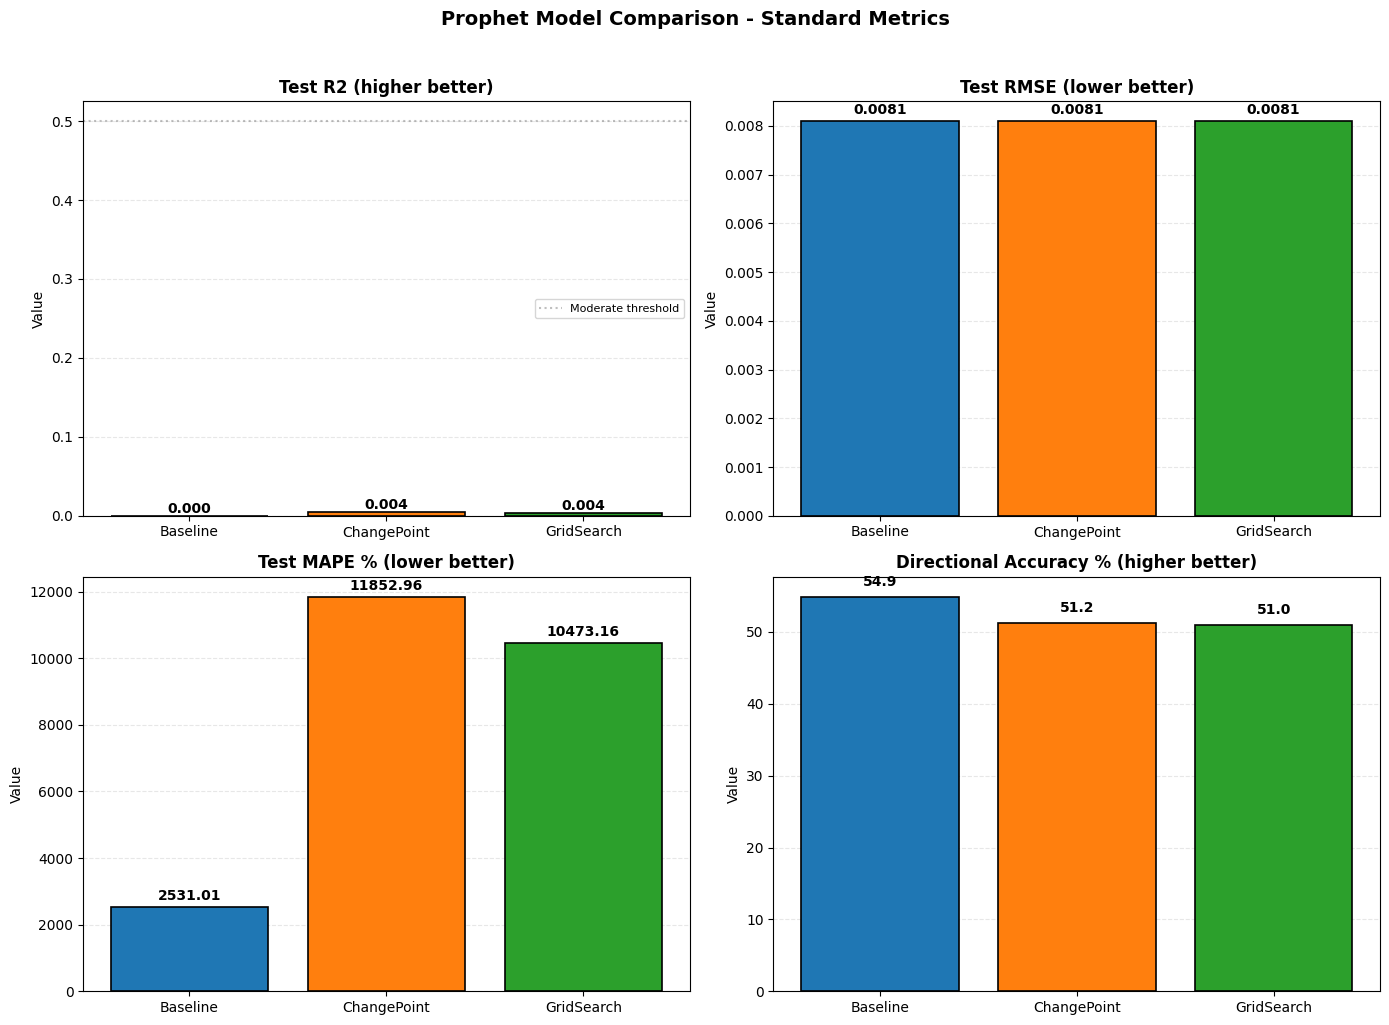

In [60]:
# figure configuration
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# model labels
model_labels = ["Baseline", "ChangePoint", "GridSearch"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# metrics conbfiguration
metrics = {
    "Test R2": {"title": "Test R2 (higher better)", "direction": "higher", "fmt": ".3f"},
    "Test RMSE": {"title": "Test RMSE (lower better)", "direction": "lower", "fmt": ".4f"},
    "Test MAPE": {"title": "Test MAPE % (lower better)", "direction": "lower", "fmt": ".2f"},
    "Test Dir Acc %": {"title": "Directional Accuracy % (higher better)", "direction": "higher", "fmt": ".1f"}
}

# prepare values dictionary
values_dict = {
    "Test R2": performance_summary["Test R2"].values,
    "Test RMSE": performance_summary["Test RMSE"].values,
    "Test MAPE": performance_summary["Test MAPE"].values,
    "Test Dir Acc %": [test_acc_baseline, test_acc_cp, test_acc_grid]
}

for i, (metric, config) in enumerate(metrics.items()):
    ax = axes[i]
    values = values_dict[metric]

    # create bar chart
    bars = ax.bar(model_labels, values, color=colors, edgecolor='black', linewidth=1.2)
    
    # add value labels on top of bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        label_pos = height + (max(values) * 0.02) if config["direction"] == "higher" else height + (max(values) * 0.01)
        ax.text(bar.get_x() + bar.get_width()/2., label_pos, f'{value:{config["fmt"]}}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # formatting
    ax.set_title(config["title"], fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    
    if metric == "Test R2":
        ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Moderate threshold')
        ax.legend(fontsize=8, frameon=True)

plt.suptitle("Prophet Model Comparison - Standard Metrics", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# save figure
figure_path = FIGURE_ROOT / "05Prophet_Comparison_StandardMetrics.png"
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

## Financial Metrics Radar Chart

In [61]:
# financial metrics
fin_metrics = ['Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Total Return (%)']

# extract metrics values
fin_values = {
    "Baseline": [
        fin_baseline['Sharpe Ratio'].values[0],
        fin_baseline['Sortino Ratio'].values[0],
        abs(fin_baseline['Max Drawdown'].values[0]),
        fin_baseline['Total Return (%)'].values[0]
    ],
    "ChangePoint": [
        fin_cp['Sharpe Ratio'].values[0],
        fin_cp['Sortino Ratio'].values[0],
        abs(fin_cp['Max Drawdown'].values[0]),
        fin_cp['Total Return (%)'].values[0]
    ],
    "GridSearch": [
        fin_grid['Sharpe Ratio'].values[0],
        fin_grid['Sortino Ratio'].values[0],
        abs(fin_grid['Max Drawdown'].values[0]),
        fin_grid['Total Return (%)'].values[0]
    ]
}

In [62]:
# normalize metrics for radar chart
def normalize_metrics(values_dict, metrics, higher_is_better=None):
    
    if higher_is_better is None:
        higher_is_better = [True, True, False, True]
    
    normalized = {}
    
    for idx, metric in enumerate(metrics):
        all_values = [values_dict[model][idx] for model in values_dict]
        min_val, max_val = min(all_values), max(all_values)
        range_val = max_val - min_val if max_val != min_val else 1
        
        for model in values_dict:
            if model not in normalized:
                normalized[model] = []
            
            val = values_dict[model][idx]
            
            # normalize
            if higher_is_better[idx]:
                norm_val = (val - min_val) / range_val
            
            else:
                norm_val = 1 - (val - min_val) / range_val      # invert for "lower is better"
            
            normalized[model].append(norm_val)
    
    return normalized

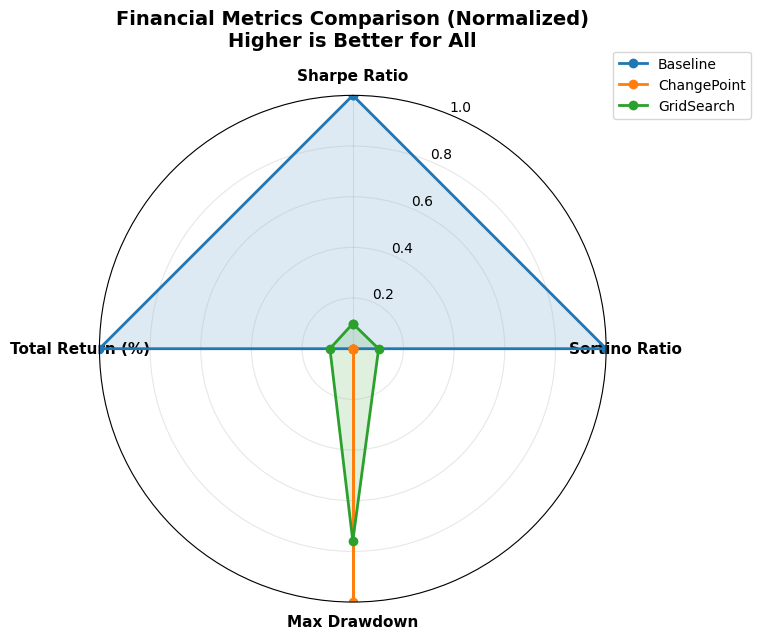

In [63]:
# radar chart for financial metrics
normalized_financial = normalize_metrics(fin_values, fin_metrics)

# create radar chart
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection='polar'))

# angle for each metric
angles = np.linspace(0, 2 * np.pi, len(fin_metrics), endpoint=False).tolist()
angles += angles[:1]

# plot each model
for model, color in zip(model_labels, colors):
    values = normalized_financial[model]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color, markersize=6)
    ax.fill(angles, values, alpha=0.15, color=color)

# formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(fin_metrics, size=11, weight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.title("Financial Metrics Comparison (Normalized)\nHigher is Better for All",
    fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
figure_path = FIGURE_ROOT / "05Prophet_Comparison_FinancialMetrics.png"

# save figure
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

# **Final Summary of Model Performances**

In [64]:
# final summary of all models performance
final_summary = pd.merge(
    performance_summary,
    overfit_df[['Model', 'R2 Gap', 'RMSE Ratio', 'Dir Acc Gap (%)',
                 'Overfitting Status', 'Model Status (Generalization)']],
    on="Model", how="outer"
)

In [65]:
print("Summary of The Models Performance:")
display(final_summary)

Summary of The Models Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,Prophet (Baseline),0.0001,0.0079,0.0110,-0.0426,49692.2080,53.1579,0.0001,0.006,0.0081,0.0001,2531.0104,54.9234,-0.0427,0.7364,1.7655,Mild,Poor
1,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316,0.0001,0.006,0.0081,0.0043,11852.9633,51.2035,-0.0615,0.7232,0.5719,Mild,Poor
2,Prophet (GridSearch),0.0001,0.0081,0.0113,-0.0956,40253.4662,49.8947,0.0001,0.006,0.0081,0.0039,10473.1597,50.9847,-0.0995,0.7168,1.0900,Mild,Poor


In [66]:
# financial metrics of all variations
financial_metrics = pd.concat([fin_baseline, fin_cp, fin_grid], axis=0).reset_index(drop=True)
display(financial_metrics)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,Prophet (Baseline),0.9381,1.2852,-15.6379,27.0766
1,Prophet (ChangePoint),-0.0160,-0.0227,-13.1703,1.7409
2,Prophet (GridSearch),0.0786,0.1107,-13.7644,4.0284


In [67]:
# best model selection based on test R2 and test RMSE with tie-breaker logic
prophet_performance = final_summary.sort_values(
    by=['Test R2', 'Test RMSE'],
    ascending=[False, True]
)

best_variant = prophet_performance.iloc[0]

In [69]:
# convert best variant performance to dataframe
best_variant = best_variant.to_frame(name='Value').rename_axis('Metrics').reset_index()

In [70]:
best_variant

,Metrics,Value
0,Model,Prophet (ChangePoint)
1,CV MSE,0.0001
2,CV MAE,0.008
3,CV RMSE,0.0112
4,CV R2,-0.0572
5,CV MAPE,24627.6569
6,CV Directional Accuracy (%),50.6316
7,Test MSE,0.0001
8,Test MAE,0.006
9,Test RMSE,0.0081


# Persist Best Model and Performance

In [71]:
# model persistor object
persister = ModelPersister(model_name="Prophet", model_root=MODEL_ROOT, performance_root=PERFORMANCE_ROOT)

In [72]:
# persist performance of all variants
persister.save_performance(prophet_performance)

performance saved: Prophet


In [73]:
# persists performance of the best variants from prophet
persister.save_performance(best_variant, "BestVariation")

performance saved: Prophet


In [74]:
# persist financial metrics of prophet model
persister.save_performance(financial_metrics, "FinancialMetrics")

performance saved: Prophet


In [75]:
# aggregated model performance
persister.aggregated_performance(prophet_performance, "AllModel_OverallPerformance")

Appended to aggregated performance!


In [76]:
# aggregated model performance
persister.aggregated_performance(financial_metrics, "AllModel_FinancialMetrics")

Appended to aggregated performance!


In [77]:
# append best variant to aggregated
persister.aggregated_performance(prophet_performance.iloc[[0]], "AllModel_BestVariant")

Appended to aggregated performance!


In [78]:
# append overfitting analysis
persister.append_overfitting(overfit_df)

Appended to overfitting analysis!


In [79]:
# save best model
best_model_name = prophet_performance.iloc[0]['Model']

if "ChangePoint" in best_model_name:
    best_model = cp_model

elif "GridSearch" in best_model_name:
    best_model = grid_model

else:
    best_model = baseline_model

persister.save_model(best_model)

Model saved: Prophet_model.json
